# Amazon Sales Analysis

In [2]:
# importing required libraries for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

In [3]:
#loading csv file
df = pd.read_csv(r'C:\Users\Scientist\Desktop\Portfolio Projects\Python\amazon_e_commerce_analysis\dataset\amazon_sale_report.csv')

C:\Users\Scientist\AppData\Local\Temp\ipykernel_12620\291096980.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\Scientist\Desktop\Portfolio Projects\Python\amazon_e_commerce_analysis\dataset\amazon_sale_report.csv')


---

## 1. Data Understaning

In [4]:
df.head(5)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


---

## 2. Data Cleaning

In [5]:
# dropping unnecessary columns
df = df.drop(columns=['Unnamed: 22','index'])

In [6]:
#checking for duplicates
df.duplicated().value_counts()

False    128969
True          6
Name: count, dtype: int64

In [7]:
#removing duplicates
df = df.drop_duplicates()
df.duplicated().value_counts()

False    128969
Name: count, dtype: int64

In [8]:
#checking data quality
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128969 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128969 non-null  object 
 1   Date                128969 non-null  object 
 2   Status              128969 non-null  object 
 3   Fulfilment          128969 non-null  object 
 4   Sales Channel       128969 non-null  object 
 5   ship-service-level  128969 non-null  object 
 6   Style               128969 non-null  object 
 7   SKU                 128969 non-null  object 
 8   Category            128969 non-null  object 
 9   Size                128969 non-null  object 
 10  ASIN                128969 non-null  object 
 11  Courier Status      122097 non-null  object 
 12  Qty                 128969 non-null  int64  
 13  currency            121177 non-null  object 
 14  Amount              121177 non-null  float64
 15  ship-city           128936 non-null  ob

In [9]:
#count of nulls according to columns
df.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7792
Amount                 7792
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49150
B2B                       0
fulfilled-by          89692
dtype: int64

In [10]:
# renaming columns
df = df.rename(columns={
    'ship-service-level':'Service Level',
    'currency':'Currency',
    'ship-city':'City',
    'ship-state':'State',
    'ship-postal-code':'Postal Code',
    'ship-country':'Country',
    'promotion-ids': 'Promotions',
    'fulfilled-by': 'Fulfilled By'
})

In [11]:
# converting Date Column to pandas datetime format
df['Date'] = pd.to_datetime(df['Date'],
                            format='%m-%d-%y',
                            errors='coerce')
df['Postal Code'] = pd.to_numeric(df['Postal Code'],errors='coerce').astype('Int64')

In [12]:
df['Category'] = df['Category'].str.title()
df['City'] = df['City'].str.title()
df['State'] = df['State'].str.title()

In [13]:
# checkin state column for typos
df['State'].unique()

array(['Maharashtra', 'Karnataka', 'Puducherry', 'Tamil Nadu',
       'Uttar Pradesh', 'Chandigarh', 'Telangana', 'Andhra Pradesh',
       'Rajasthan', 'Delhi', 'Haryana', 'Assam', 'Jharkhand',
       'Chhattisgarh', 'Odisha', 'Kerala', 'Madhya Pradesh',
       'West Bengal', 'Nagaland', 'Gujarat', 'Uttarakhand', 'Bihar',
       'Jammu & Kashmir', 'Punjab', 'Himachal Pradesh',
       'Arunachal Pradesh', 'Manipur', 'Goa', 'Meghalaya', 'Tripura',
       'Ladakh', 'Dadra And Nagar', 'Sikkim', nan, 'Andaman & Nicobar ',
       'Rajshthan', 'Nl', 'Mizoram', 'New Delhi',
       'Punjab/Mohali/Zirakpur', 'Rj', 'Orissa', 'Lakshadweep', 'Pb',
       'Apo', 'Ar', 'Pondicherry', 'Rajsthan'], dtype=object)

In [14]:
# cleaning state column
df['State'] = df['State'].str.strip()
state_correction = {
    'Rajshthan': 'Rajasthan',
    'Rj': 'Rajasthan',
    'Rajsthan': 'Rajasthan',
    'Pb': 'Punjab',
    'Orissa': 'Odisha',
    'Ar': 'Arunachal Pradesh',
    'Pondicherry': 'Puducherry',
    'Poducherry': 'Puducherry',  
    'Dadra And Nagar': 'Dadra and Nagar Haveli and Daman and Diu',
    'New Delhi': 'Delhi',
    'Punjab/Mohali/Zirakpur': 'Punjab',
    'Nl': 'Nagaland',
    'Apo': 'Unknown'

}
df['State'] = df['State'].replace(state_correction)

In [15]:
df['State'].unique()

array(['Maharashtra', 'Karnataka', 'Puducherry', 'Tamil Nadu',
       'Uttar Pradesh', 'Chandigarh', 'Telangana', 'Andhra Pradesh',
       'Rajasthan', 'Delhi', 'Haryana', 'Assam', 'Jharkhand',
       'Chhattisgarh', 'Odisha', 'Kerala', 'Madhya Pradesh',
       'West Bengal', 'Nagaland', 'Gujarat', 'Uttarakhand', 'Bihar',
       'Jammu & Kashmir', 'Punjab', 'Himachal Pradesh',
       'Arunachal Pradesh', 'Manipur', 'Goa', 'Meghalaya', 'Tripura',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu', 'Sikkim',
       nan, 'Andaman & Nicobar', 'Mizoram', 'Lakshadweep', 'Unknown'],
      dtype=object)

In [16]:
df['City'].unique().tolist()

['Mumbai',
 'Bengaluru',
 'Navi Mumbai',
 'Puducherry',
 'Chennai',
 'Ghaziabad',
 'Chandigarh',
 'Hyderabad',
 'Noida',
 'Amravati.',
 'Guntakal',
 'Jaipur',
 'New Delhi',
 'Gurgaon',
 'Tiruchirappalli',
 'Pune',
 'Tezpur',
 'Ranchi',
 'Bilaspur',
 'Guwahati',
 'Thiruvarur',
 'Lucknow',
 'Visakhapatnam',
 'Jeypur',
 'Thiruvananthapuram',
 'Greater Noida',
 'Jabalpur',
 'Kolkata',
 'Ongole',
 'Secunderabad',
 'Kewalpur',
 'Cuttack',
 'Badlapur',
 'Dimapur',
 'Warangal',
 'Dhaulpur',
 'Nagpur',
 'Thane',
 'Dahod',
 'Vijapura',
 'Bangalore',
 'Berhampur',
 'Himmatnagar',
 'Dehradun',
 'Dharmapuri',
 'Vadodara',
 'Chavakkad',
 'Patna',
 'Jammu',
 'Narnaund',
 'Ahmedabad',
 'Ambarnath',
 'Gwalior',
 'Rohtak',
 'Ramagundam',
 'Pithoragarh',
 'Guwahati, Kamrup (M)',
 'Kolar',
 'Patiala',
 'Rewa',
 'Bongaigaon',
 'Chengalpattu',
 'Perambalur',
 'Varanasi',
 'Coimbatore',
 'Chirmiri',
 'Azamgarh',
 'Kalyan',
 'Mysore',
 'Barabanki',
 'Amila',
 'Vijayawada',
 'Rawan Ambuja Cement Plant',
 'Herb

In [17]:
import re

# Basic text cleanup (spaces, lowercase consistency if desired)
df['City'] = df['City'].astype(str).str.strip()

# Clean out Pincodes, Brackets, and Delivery Notes using Regex
df['City'] = (
    df['City']
    .str.replace(r'\(.*?\)', '', regex=True)      # Removes text in brackets e.g. (Amazon)
    .str.replace(r'\b\d{6}\b', '', regex=True)     # Removes 6-digit Pincodes
    .str.replace(r'[^\w\s,]', '', regex=True)     # Removes special punctuation like '.' or '-'
    .str.strip()
)

# to handle comma-separated location tags (takes the primary name)
df['City'] = df['City'].apply(lambda x: x.split(',')[0].strip() if ',' in x else x)

# dictionary for explicit typos and older city names
city_map = {
    'Bangalore': 'Bengaluru',
    'Gurgaon': 'Gurugram',
    'Cochin': 'Kochi',
    'Trivandrum': 'Thiruvananthapuram',
    'Mysore': 'Mysuru',
    'Pondycherry': 'Puducherry',
    'Allahabad': 'Prayagraj',
    'Amravati': 'Amravati',
    'Kanpurkanpur': 'Kanpur',
    'Lucknowlucknow': 'Lucknow',
    'Udaipurudipur': 'Udaipur',
    'Ahemdabad': 'Ahmedabad',
    'Ankleshwr': 'Ankleshwar',
    'Varanas': 'Varanasi',
    'Dobiwali': 'Dombivli',
    'Dombivali East': 'Dombivli',
    'Dombivli West': 'Dombivli',
    'Chandigar': 'Chandigarh',
    'Poducherry': 'Puducherry',
    'New Delhihbjo': 'New Delhi',
}

df['City'] = df['City'].replace(city_map)

In [18]:
# checking null values in Courier Status Column
df[df['Courier Status'].isnull()]['Status'].value_counts()

Status
Cancelled                       6861
Shipped - Delivered to Buyer       8
Shipped - Returned to Seller       3
Name: count, dtype: int64

In [19]:
# non null value count in Courier Status column
df[df['Courier Status'].notna()]['Courier Status'].value_counts()

Courier Status
Shipped      109484
Unshipped      6681
Cancelled      5932
Name: count, dtype: int64

In [20]:
# cleaning up Courier Status Column
conditions = [df['Courier Status'].isna() & (df['Status']=='Cancelled'),
              df['Courier Status'].isna() & (df['Status'].str.startswith('Shipped'))
]
choices = ['Cancelled','Shipped']
df['Courier Status'] = np.select(conditions,choices,default=df['Courier Status'])

In [21]:
# checking Courier Status column after cleanup
df['Courier Status'].isnull().value_counts()

Courier Status
False    128969
Name: count, dtype: int64

In [22]:
# checking non null values in Currency Column
df[df['Currency'].notna()]['Currency'].value_counts()

Currency
INR    121177
Name: count, dtype: int64

In [23]:
# checking count of values in Ship Country column where Currency is null
df[df['Currency'].isnull()]['Country'].value_counts()

Country
IN    7790
Name: count, dtype: int64

In [24]:
# fill null values in currency column with INR as dataset is of Country India
df['Currency'] = df['Currency'].fillna('INR')

In [25]:
# null values in amount column
df['Amount'].isna().sum()

7792

In [26]:
# comparing mean and median of Amount column to check skewness
df['Amount'].mean(),df['Amount'].median()

(648.5557762611718, 605.0)

In [27]:
# replacing null in Amount column with median Amount of that specific SKU
df['Amount'] = df['Amount'].fillna(df.groupby('SKU')['Amount'].transform('median'))

In [28]:
# count of other column where Ship City is null
df[df['City'].isnull()].count()

Order ID          0
Date              0
Status            0
Fulfilment        0
Sales Channel     0
Service Level     0
Style             0
SKU               0
Category          0
Size              0
ASIN              0
Courier Status    0
Qty               0
Currency          0
Amount            0
City              0
State             0
Postal Code       0
Country           0
Promotions        0
B2B               0
Fulfilled By      0
dtype: int64

In [29]:
# filling null values in each geographical column with Unknown as per inspection
df['City'] = df['City'].fillna('Unknown')
df['State'] = df['State'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')

In [30]:
# checking null value count of Fulfilment Column where Fulfilled By is null
df[df['Fulfilled By'].isna()]['Fulfilment'].value_counts()

Fulfilment
Amazon    89692
Name: count, dtype: int64

In [31]:
# filling null values in Fulfilled By with Amazon
df['Fulfilled By'] = df['Fulfilled By'].fillna('Amazon')

In [32]:
df['Promotions'].isnull().sum()

49150

In [33]:
# filling null values in Promotion column with No Promotions
df['Promotions'] = df['Promotions'].fillna('No Promotions')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128969 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Order ID        128969 non-null  object        
 1   Date            128969 non-null  datetime64[ns]
 2   Status          128969 non-null  object        
 3   Fulfilment      128969 non-null  object        
 4   Sales Channel   128969 non-null  object        
 5   Service Level   128969 non-null  object        
 6   Style           128969 non-null  object        
 7   SKU             128969 non-null  object        
 8   Category        128969 non-null  object        
 9   Size            128969 non-null  object        
 10  ASIN            128969 non-null  object        
 11  Courier Status  128969 non-null  object        
 12  Qty             128969 non-null  int64         
 13  Currency        128969 non-null  object        
 14  Amount          128925 non-null  float64 

In [35]:
df.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Order ID,405-8078784-5731545,171-9198151-1101146,404-0687676-7273146,403-9615377-8133951,407-1069790-7240320,404-1490984-4578765,408-5748499-6859555,406-7807733-3785945,407-5443024-5233168,402-4393761-0311520,407-5633625-6970741,171-4638481-6326716,405-5513694-8146768,408-7955685-3083534,408-1298370-1920302,403-4965581-9520319,406-9379318-6555504,405-9013803-8009918,402-4030358-5835511,405-5957858-1051546
Date,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00
Status,Cancelled,Shipped - Delivered to Buyer,Shipped,Cancelled,Shipped,Shipped,Shipped,Shipped - Delivered to Buyer,Cancelled,Shipped,Shipped,Shipped,Shipped - Delivered to Buyer,Shipped,Shipped - Delivered to Buyer,Shipped - Delivered to Buyer,Shipped,Shipped,Shipped - Delivered to Buyer,Shipped
Fulfilment,Merchant,Merchant,Amazon,Merchant,Amazon,Amazon,Amazon,Merchant,Amazon,Amazon,Amazon,Amazon,Merchant,Amazon,Merchant,Merchant,Amazon,Amazon,Merchant,Amazon
Sales Channel,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in
Service Level,Standard,Standard,Expedited,Standard,Expedited,Expedited,Expedited,Standard,Expedited,Expedited,Expedited,Expedited,Standard,Expedited,Standard,Standard,Expedited,Expedited,Standard,Expedited
Style,SET389,JNE3781,JNE3371,J0341,JNE3671,SET264,J0095,JNE3405,SET200,JNE3461,JNE3160,JNE3500,JNE3405,SET182,J0351,PJNE3368,JNE3721,JNE3405,JNE3697,SET254
SKU,SET389-KR-NP-S,JNE3781-KR-XXXL,JNE3371-KR-XL,J0341-DR-L,JNE3671-TU-XXXL,SET264-KR-NP-XL,J0095-SET-L,JNE3405-KR-S,SET200-KR-NP-A-XXXL,JNE3461-KR-XXL,JNE3160-KR-G-S,JNE3500-KR-XS,JNE3405-KR-XS,SET182-KR-DH-XS,J0351-SET-L,PJNE3368-KR-6XL,JNE3721-KR-XXL,JNE3405-KR-XL,JNE3697-KR-XXL,SET254-KR-NP-XS
Category,Set,Kurta,Kurta,Western Dress,Top,Set,Set,Kurta,Set,Kurta,Kurta,Kurta,Kurta,Set,Set,Kurta,Kurta,Kurta,Kurta,Set
Size,S,3XL,XL,L,3XL,XL,L,S,3XL,XXL,S,XS,XS,XS,L,6XL,XXL,XL,XXL,XS


In [36]:
# checking status column
df['Status'].value_counts()

Status
Shipped                          77801
Shipped - Delivered to Buyer     28769
Cancelled                        18329
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [37]:
# categorizing Status in 5 different buckets
cn_shipped = ['Shipped','Shipped - Picked Up',
              'Shipped - Out for Delivery']
cn_delivered = ['Shipped - Delivered to Buyer']
cn_cancelled = ['Cancelled']
cn_returned = ['Shipped - Returned to Seller','Shipped - Returning to Seller','Shipped - Rejected by Buyer']
cn_pending = ['Pending','Pending - Waiting for Pick Up', 'Shipped - Lost in Transit', 'Shipped - Damaged','Shipping']
cond = [
    df['Status'].isin(cn_shipped),
    df['Status'].isin(cn_delivered),
    df['Status'].isin(cn_cancelled),
    df['Status'].isin(cn_returned),
    df['Status'].isin(cn_pending)
]
choices = ['Shipped', 'Delivered', 'Cancelled', 'Returned', 'Pending']
df['Order Status Group'] = np.select(cond, choices,default='Other')
df['Order Status Group'].value_counts()

Order Status Group
Shipped      78809
Delivered    28769
Cancelled    18329
Returned      2109
Pending        953
Name: count, dtype: int64

---

## 3. Exploratory Data Analysis

In [38]:
df.describe()

,Date,Qty,Amount,Postal Code
count,128969,128969.00000,128925.000000,128936.0
mean,2022-05-12 11:50:02.758802176,0.90445,648.871274,463966.663314
min,2022-03-31 00:00:00,0.00000,0.000000,110001.0
25%,2022-04-20 00:00:00,1.00000,449.000000,382421.0
50%,2022-05-10 00:00:00,1.00000,605.000000,500033.0
75%,2022-06-04 00:00:00,1.00000,788.000000,600024.0
max,2022-06-29 00:00:00,15.00000,5584.000000,989898.0
std,NaN,0.31333,280.402058,191475.01846


In [39]:
df[df['Qty']>1].head(20).T

,265,647,937,1018,1057,1696,2107,2185,2189,2583,3289,3631,3636,3637,5320,6455,6576,6865,7401,8213
Order ID,171-6655820-6440356,171-6153595-4758722,S02-5278980-4327051,171-2730956-8469920,S02-9107114-0460608,404-9817487-8322703,405-7829062-0073141,406-0317784-3647538,407-8699712-7129943,402-8508102-8205929,406-3338330-9401954,S02-1006261-5356758,S02-6828927-1180856,S02-3409426-0744131,403-1935444-4523543,171-9946092-6261964,404-3217378-7080364,404-4247115-4590734,404-7172757-2090740,406-7075116-6878750
Date,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-30 00:00:00,2022-04-29 00:00:00,2022-04-29 00:00:00,2022-04-29 00:00:00,2022-04-29 00:00:00,2022-04-29 00:00:00,2022-04-28 00:00:00,2022-04-28 00:00:00,2022-04-28 00:00:00,2022-04-28 00:00:00,2022-04-27 00:00:00,2022-04-26 00:00:00,2022-04-26 00:00:00,2022-04-26 00:00:00,2022-04-25 00:00:00,2022-04-25 00:00:00
Status,Shipped,Shipped,Shipped,Cancelled,Shipped,Shipped,Shipped - Returned to Seller,Shipped,Shipped,Shipped,Shipped - Delivered to Buyer,Shipped,Shipped,Shipped,Shipped,Shipped - Delivered to Buyer,Shipped - Delivered to Buyer,Shipped - Delivered to Buyer,Shipped - Delivered to Buyer,Shipped - Delivered to Buyer
Fulfilment,Amazon,Amazon,Amazon,Amazon,Amazon,Amazon,Merchant,Amazon,Amazon,Amazon,Merchant,Amazon,Amazon,Amazon,Amazon,Merchant,Merchant,Merchant,Merchant,Merchant
Sales Channel,Amazon.in,Amazon.in,Non-Amazon,Amazon.in,Non-Amazon,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Non-Amazon,Non-Amazon,Non-Amazon,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in,Amazon.in
Service Level,Expedited,Expedited,Standard,Expedited,Standard,Expedited,Standard,Expedited,Expedited,Expedited,Standard,Standard,Standard,Standard,Expedited,Standard,Standard,Standard,Standard,Standard
Style,J0008,J0230,BL017,SET183,SET315,J0003,JNE3365,JNE3465,JNE3645,JNE2171,JNE3798,JNE2305,JNE2305,BL020,J0190,JNE3363,MEN5015,SET265,JNE3546,J0332
SKU,J0008-SKD-XXL,J0230-SKD-S,BL017-63BLACK,SET183-KR-DH-XXXL,SET315-KR-PP-XL,J0003-SET-M,JNE3365-KR-1052-A-S,JNE3465-KR-XXL,JNE3645-TP-N-M,JNE2171-KR-437-XL,JNE3798-KR-M,JNE2305-KR-533-L,JNE2305-KR-533-XXL,BL020-71RED,J0190-TP-L,JNE3363-KR-1032-XXL,MEN5015-KR-M,SET265-KR-NP-XS,JNE3546-KR-S,J0332-DR-S
Category,Set,Set,Blouse,Set,Set,Set,Kurta,Kurta,Top,Kurta,Western Dress,Kurta,Kurta,Blouse,Top,Kurta,Kurta,Set,Kurta,Western Dress
Size,XXL,S,Free,3XL,XL,M,S,XXL,M,XL,M,L,XXL,Free,L,XXL,M,XS,S,S


In [40]:
# overall business overview
total_orders = df['Order ID'].nunique()
total_quantity_sold = df[df['Order Status Group'].isin(['Delivered','Shipped'])]['Qty'].sum()
total_shipped_orders = df[df['Order Status Group'].isin(['Delivered','Shipped'])]['Order ID'].nunique()
total_revenue = df[df['Order Status Group'].isin(['Delivered','Shipped'])]['Amount'].sum()
average_order_value = total_revenue/total_shipped_orders
cancellation_rate = df[df['Order Status Group']=='Cancelled']['Order ID'].nunique()/total_orders
order_status_distribution = df['Order Status Group'].value_counts().reset_index(name='Total Orders')
print(
    f'''
Total Orders:           {total_orders:,}
Total Quantity Sold:    {total_quantity_sold:,}
Total Revenue:          {total_revenue:,.2f}
Average Order Value:    {average_order_value:,.2f}
Cancellation Rate:      {cancellation_rate:.2%}
'''
)
order_status_distribution


Total Orders:           120,378
Total Quantity Sold:    107,904
Total Revenue:          69,795,046.09
Average Order Value:    695.57
Cancellation Rate:      14.28%



,Order Status Group,Total Orders
0,Shipped,78809
1,Delivered,28769
2,Cancelled,18329
3,Returned,2109
4,Pending,953


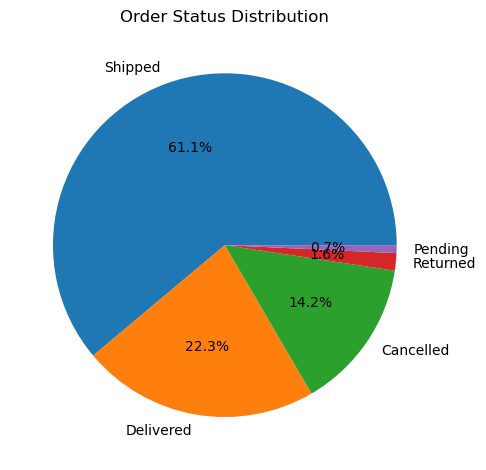

In [41]:
plt.pie(order_status_distribution['Total Orders'],labels=order_status_distribution['Order Status Group'],autopct='%1.1f%%')
plt.title('Order Status Distribution')
plt.tight_layout()
plt.show()

---

### Overall Business Overview

**Observations:**
- The dataset contains 120,378 unique orders after data cleaning.
- 107,904 units were sold across shipped and delivered orders.
- Total revenue from shipped and delivered orders was approximately ₹6.98 Cr.
- The average order value was approximately ₹695.57.
- The overall cancellation rate was 14.28%, with 18,329 cancelled orders.

---

### Time Analysis

In [42]:
# monthly orders
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()
monthly_orders = df.groupby(['Month','Month Name'])['Order ID'].nunique().reset_index(name='Total Orders').sort_values(by='Month')
monthly_orders[1:]     # as per our dataset had only Q2 sales

,Month,Month Name,Total Orders
1,4,April,45858
2,5,May,39221
3,6,June,35141


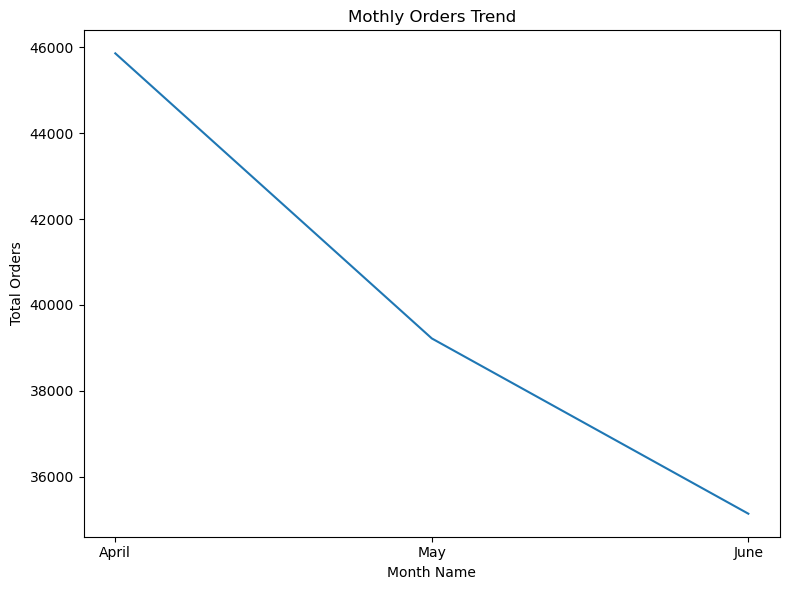

In [43]:
plt.figure(figsize=(8,6))
sns.lineplot(data=monthly_orders[1:],x='Month Name',y='Total Orders')
plt.title('Mothly Orders Trend')
plt.tight_layout()
plt.show()

---

### Monthly Orders

**Observations:**
- April recorded the highest order volume with 45,858 orders.
- Orders declined to 39,221 in May and further to 35,141 in June.
- This represents a consistent decline in order volume across the available period.

---

In [44]:
# created revenue_df to calculate revenue of orders which are Sipped or Delivered
revenue_df = df[df['Order Status Group'].isin(['Delivered','Shipped'])]

---

In [45]:
# monthly revenue
monthly_revenue = revenue_df.groupby(['Month','Month Name'])['Amount'].sum().reset_index(name='Total Revenue').sort_values(by='Month')
monthly_revenue['Total Revenue'] = monthly_revenue['Total Revenue'].round(2)
monthly_revenue[1:]

,Month,Month Name,Total Revenue
1,4,April,25724404.5
2,5,May,23505119.6
3,6,June,20470848.0


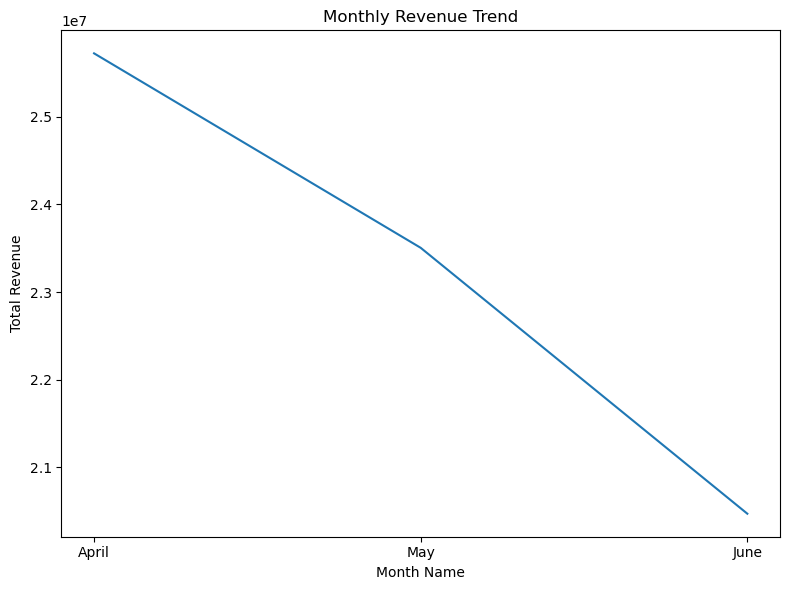

In [46]:
plt.figure(figsize=(8,6))
sns.lineplot(data=monthly_revenue[1:],x='Month Name',y='Total Revenue')
plt.title('Monthly Revenue Trend')
plt.tight_layout()
plt.show()

---

### Monthly Revenue

**Observations:**
- April generated approximately ₹2.57 Cr in revenue.
- Revenue declined to approximately ₹2.35 Cr in May and ₹2.05 Cr in June.
- Revenue therefore followed the same downward pattern as order volume.

---

In [47]:
# monthly quantity sold
monthly_qty_sold = revenue_df.groupby(['Month','Month Name'])['Qty'].sum().reset_index(name='Total Quantity').sort_values(by='Month')
monthly_qty_sold[1:]

,Month,Month Name,Total Quantity
1,4,April,41188
2,5,May,35526
3,6,June,31039


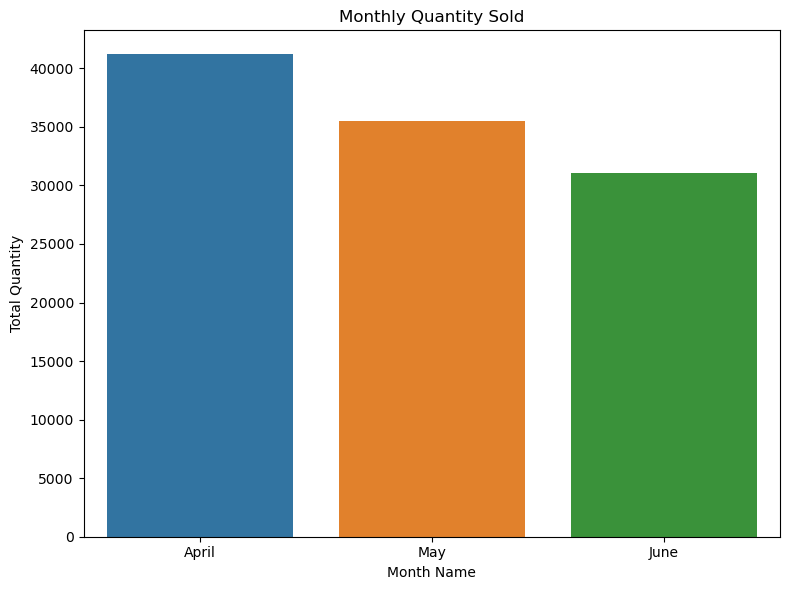

In [48]:
plt.figure(figsize=(8,6))
sns.barplot(data=monthly_qty_sold[1:],x='Month Name',y='Total Quantity')
plt.title('Monthly Quantity Sold')
plt.tight_layout()
plt.show()

---

### Quantity Sold

**Observations:**
- April recorded the highest quantity sold with 41,188 units.
- Quantity sold declined to 35,526 units in May and 31,039 units in June.
- The decline in quantity sold was consistent with the reduction in orders and revenue.

---

In [49]:
# revenue by days
df['Day Name'] = df['Date'].dt.day_name()
df['Day'] = df['Date'].dt.weekday
revenue_df = df[df['Order Status Group'].isin(['Shipped','Delivered'])]
daily_rev = revenue_df.groupby(['Day','Day Name'])['Amount'].sum().reset_index(name='Total Revenue').sort_values(by='Day')
daily_rev['Total Revenue'] = daily_rev['Total Revenue'].round(2)
daily_rev

,Day,Day Name,Total Revenue
0,0,Monday,10068052.0
1,1,Tuesday,10013510.5
2,2,Wednesday,9816051.5
3,3,Thursday,9312813.0
4,4,Friday,9671242.1
5,5,Saturday,10130302.5
6,6,Sunday,10783074.5


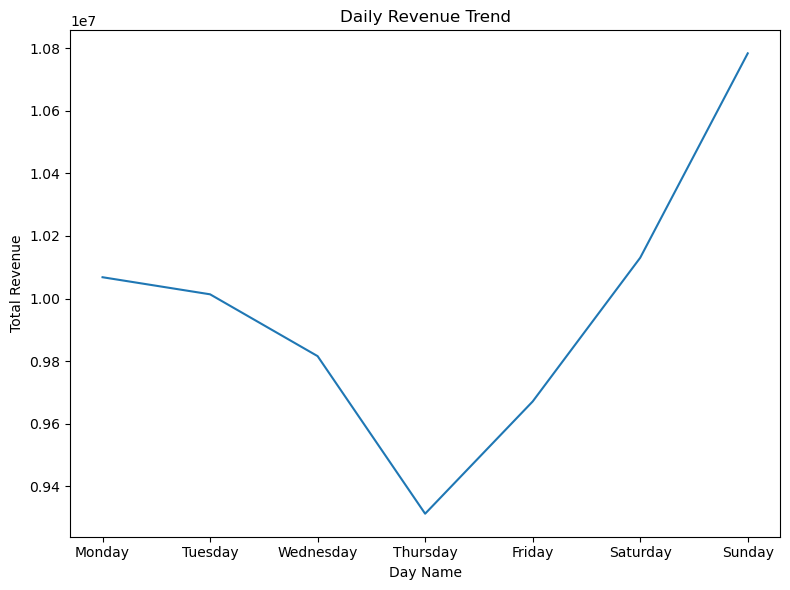

In [50]:
plt.figure(figsize=(8,6))
sns.lineplot(data=daily_rev,x='Day Name',y='Total Revenue')
plt.title('Daily Revenue Trend')
plt.tight_layout()
plt.show()

---


### Revenue by Day of Week

**Observations:**
- Sunday generated the highest aggregate revenue at approximately ₹1.08 Cr.
- Thursday generated the lowest aggregate revenue at approximately ₹93.1 Lakh.
- Revenue was relatively distributed across the week, with Sunday showing the strongest aggregate performance.

---

### Geographical Exporation

In [51]:
orders_by_state = revenue_df.groupby('State')['Order ID'].nunique().sort_values(ascending=False).reset_index(name='Total Orders')
orders_by_state

,State,Total Orders
0,Maharashtra,17597
1,Karnataka,13773
2,Tamil Nadu,8853
3,Telangana,8678
4,Uttar Pradesh,8234
5,Delhi,5604
6,Kerala,4898
7,West Bengal,4652
8,Andhra Pradesh,4033
9,Haryana,3534


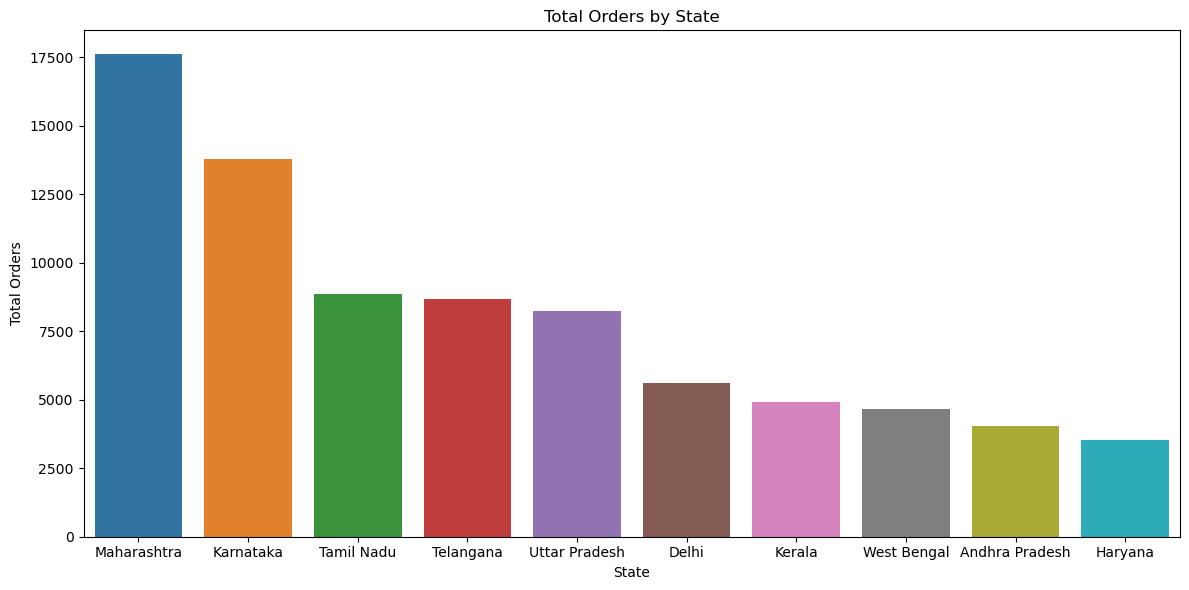

In [52]:
top10_states_by_orders = orders_by_state.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10_states_by_orders,x='State',y='Total Orders')
plt.title('Total Orders by State')
plt.tight_layout()
plt.show()

In [53]:
# revenue by state
top10_states_by_revenue = revenue_df.groupby('State')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue').head(10)
top10_states_by_revenue['Total Revenue'] = top10_states_by_revenue['Total Revenue'].round(2)
top10_states_by_revenue

,State,Total Revenue
0,Maharashtra,11967612.6
1,Karnataka,9437895.0
2,Telangana,6128673.0
3,Uttar Pradesh,5972119.0
4,Tamil Nadu,5818039.0
5,Delhi,3952479.0
6,Kerala,3302957.0
7,West Bengal,3099140.0
8,Andhra Pradesh,2800502.0
9,Haryana,2591811.9


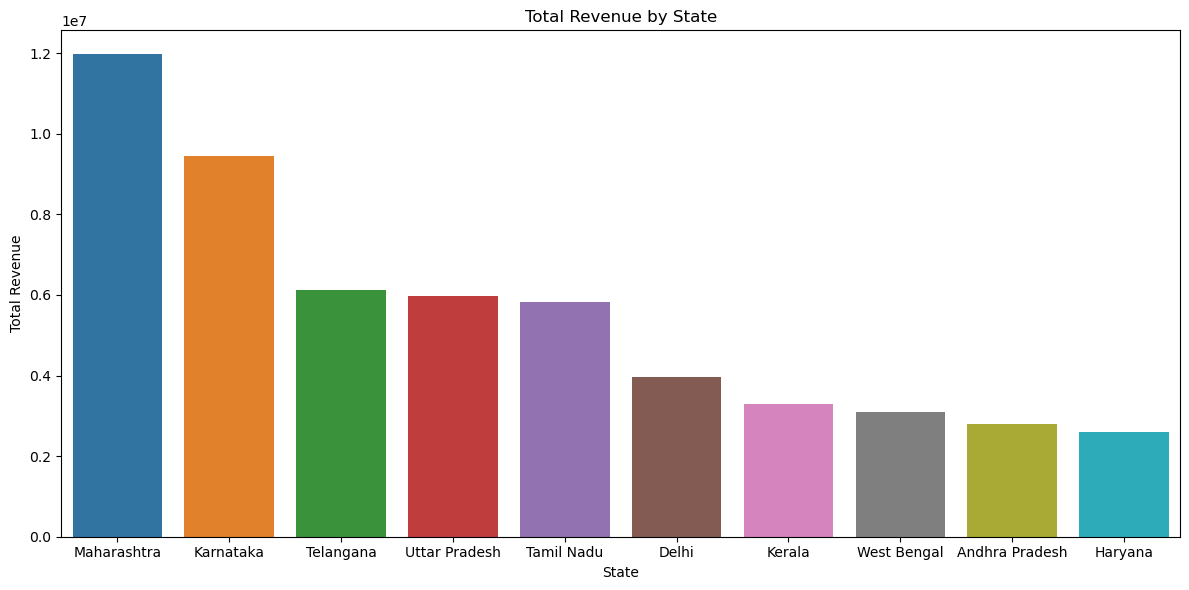

In [54]:
plt.figure(figsize=(12,6))
sns.barplot(data=top10_states_by_revenue,x='State',y='Total Revenue')
plt.title('Total Revenue by State')
plt.tight_layout()
plt.show()

---


### Revenue by State

**Observations:**
- Maharashtra generated the highest revenue at approximately ₹1.20 Cr.
- Karnataka generated approximately ₹94.38 Lakh in revenue.
- Telangana, Uttar Pradesh and Tamil Nadu were among the next highest-revenue states.


---

In [55]:
# orders by city
orders_by_city = revenue_df.groupby('City')['Order ID'].nunique().sort_values(ascending=False).reset_index(name='Total Orders')
orders_by_city

,City,Total Orders
0,Bengaluru,10732
1,Hyderabad,7017
2,Mumbai,5746
3,New Delhi,5045
4,Chennai,4914
...,...,...
6058,Old Delhi,1
6059,Chekkanoorani,1
6060,Old Mathigiri,1
6061,Chegunta,1


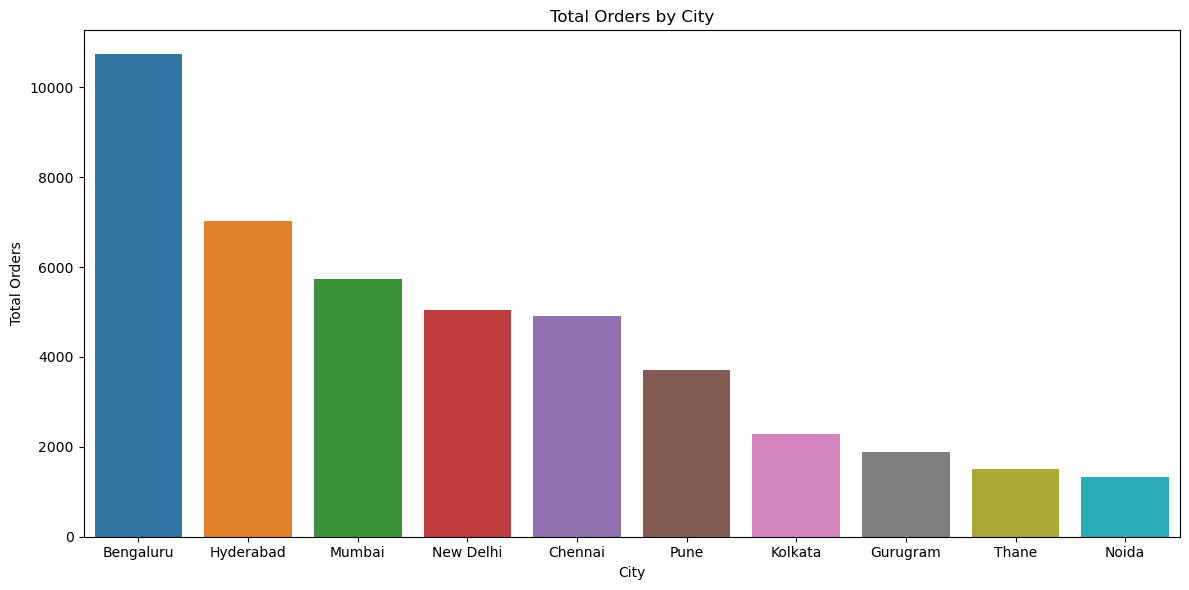

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(data=orders_by_city.head(10),x='City',y='Total Orders')
plt.title('Total Orders by City')
plt.tight_layout()
plt.show()

In [57]:
# revenue by city
revenue_by_city = revenue_df.groupby('City')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_city

,City,Total Revenue
0,Bengaluru,7373110.0
1,Hyderabad,4961248.0
2,Mumbai,3937228.0
3,New Delhi,3556667.0
4,Chennai,3248027.0
...,...,...
6058,Kilapavoor,241.0
6059,Mathabhanga,0.0
6060,Haringhata,0.0
6061,Balapur Midc,0.0


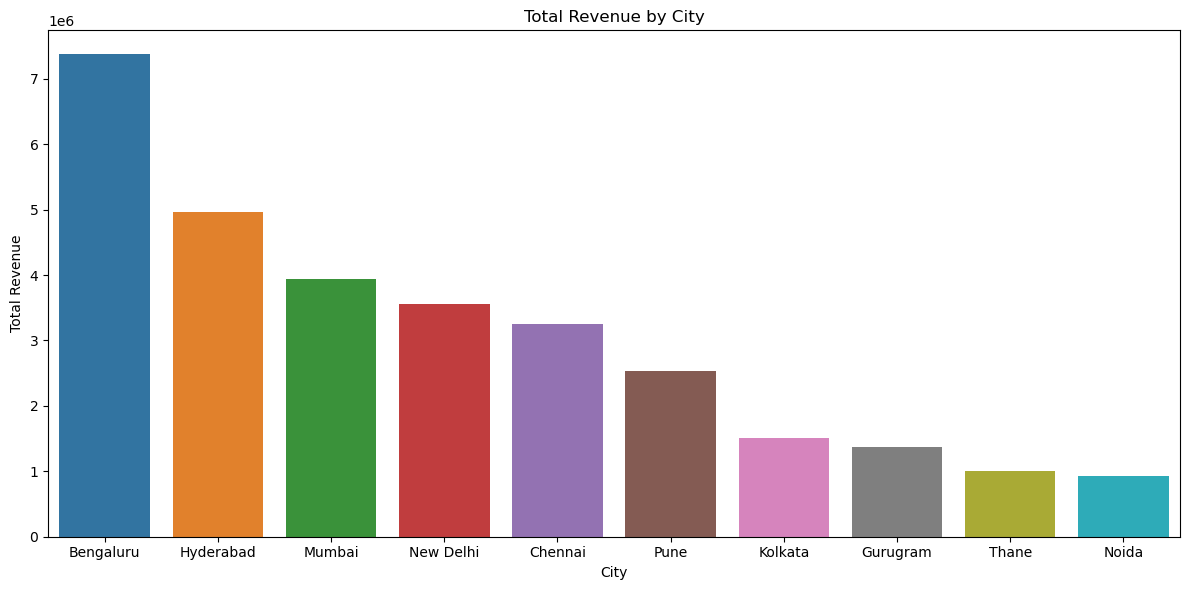

In [58]:
plt.figure(figsize=(12,6))
sns.barplot(data=revenue_by_city.head(10),x='City',y='Total Revenue')
plt.title('Total Revenue by City')
plt.tight_layout()
plt.show()

---


### Revenue by City

**Observations:**
- Bengaluru generated the highest city-level revenue at approximately ₹73.73 Lakh.
- Hyderabad generated approximately ₹49.61 Lakh in revenue.
- Mumbai, New Delhi and Chennai were among the next highest contributors.


---

### Product Analysis

In [59]:
# revenue by category
revenue_by_category = revenue_df.groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_category['Total Revenue'] = revenue_by_category['Total Revenue'].round(2)
revenue_by_category

,Category,Total Revenue
0,Set,34815522.14
1,Kurta,18971119.60
2,Western Dress,9834195.36
3,Top,4799827.00
4,Ethnic Dress,716188.00
5,Blouse,410711.00
6,Bottom,132872.00
7,Saree,113696.00
8,Dupatta,915.00


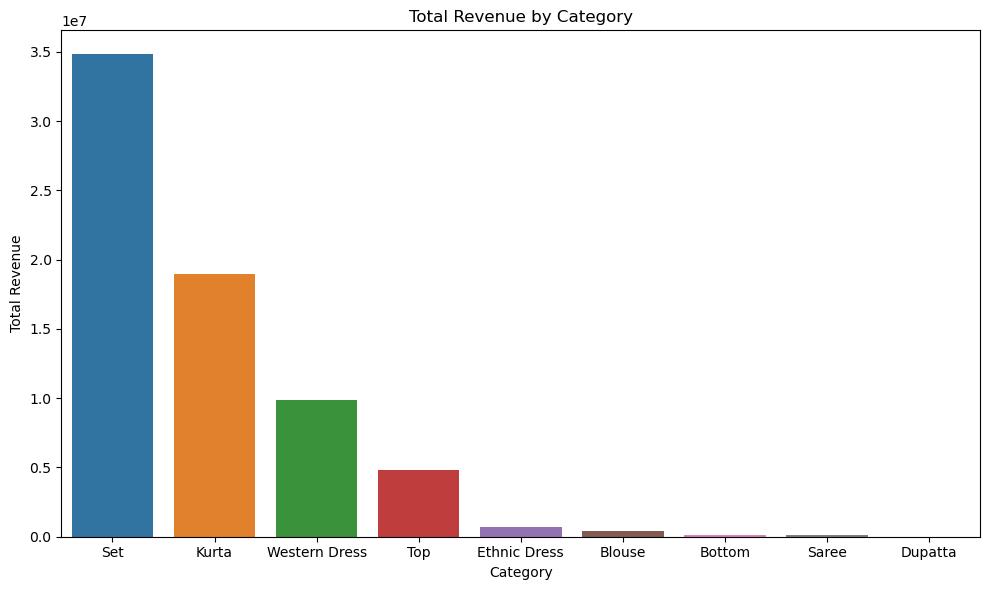

In [60]:
plt.figure(figsize=(10,6))
sns.barplot(data=revenue_by_category,x='Category',y='Total Revenue')
plt.title('Total Revenue by Category')
plt.tight_layout()
plt.show()

---

### Revenue by Category

**Observations:**
- Set was the highest-revenue category, generating approximately ₹3.48 Cr.
- Kurta was the second-largest category with approximately ₹1.90 Cr.
- Western Dress generated approximately ₹98.34 Lakh.
- Revenue was heavily concentrated among the leading product categories.


---

In [61]:
# revenue by size
revenue_by_size = revenue_df.groupby('Size')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_size['Total Revenue'] = revenue_by_size['Total Revenue'].round(2)
revenue_by_size

,Size,Total Revenue
0,M,12232700.50
1,L,11741132.00
2,XL,11073068.36
3,XXL,9527921.90
4,S,9392232.24
5,3XL,8242239.10
6,XS,6170513.00
7,6XL,535635.00
8,5XL,388897.00
9,4XL,304093.00


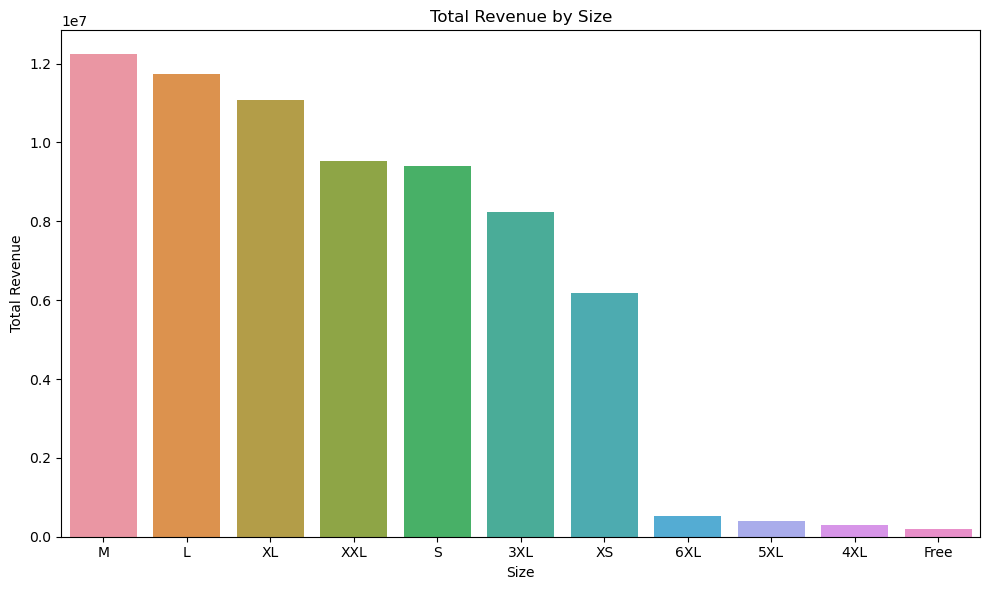

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(data=revenue_by_size,x='Size',y='Total Revenue')
plt.title('Total Revenue by Size')
plt.tight_layout()
plt.show()

---

### Revenue by Size

**Observations:**
- M was the highest-revenue size, generating approximately ₹1.22 Cr.
- L and XL followed with approximately ₹1.17 Cr and ₹1.11 Cr, respectively.
- Revenue was concentrated mainly among the M, L, XL, XXL and S size segments.


---

In [63]:
# revenue by sku
revenue_by_sku = revenue_df.groupby('SKU')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_sku['Total Revenue'] = revenue_by_sku['Total Revenue'].round(2)
revenue_by_sku

,SKU,Total Revenue
0,J0230-SKD-M,479750.0
1,JNE3797-KR-L,439562.0
2,J0230-SKD-S,436032.0
3,JNE3797-KR-M,376370.0
4,JNE3797-KR-S,340662.0
...,...,...
7090,JNE3783-KR-XS,0.0
7091,JNE3788-KR-L,0.0
7092,JNE2251-KR-537-S,0.0
7093,JNE2058-KR-339-L,0.0


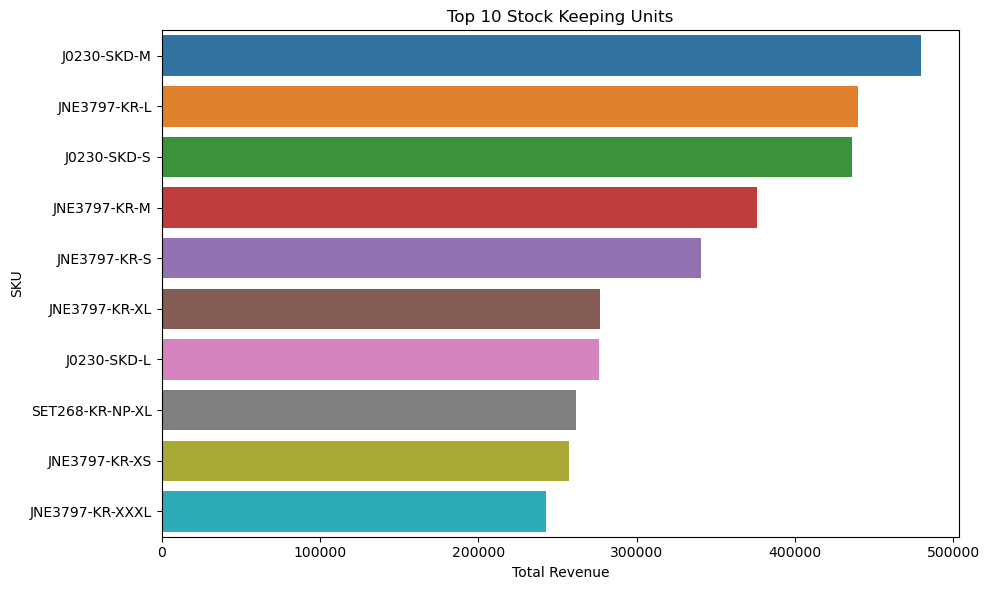

In [64]:
plt.figure(figsize=(10,6))
sns.barplot(data=revenue_by_sku.head(10),x='Total Revenue',y='SKU')
plt.title('Top 10 Stock Keeping Units')
plt.tight_layout()
plt.show()

---

### Top SKUs

**Observations:**
- A relatively small group of SKUs generated a significant amount of revenue.
- J0230-SKD-M was the highest-revenue SKU, generating approximately ₹4.80 Lakh.
- JNE3797-KR-L, J0230-SKD-S and JNE3797-KR-M were also among the top-performing SKUs.


---

### Operational Analysis

In [65]:
# orders by fulfilment
orders_by_fulfilment = revenue_df.groupby('Fulfilment')['Order ID'].nunique().sort_values(ascending=False).reset_index(name='Total Orders')
orders_by_fulfilment

,Fulfilment,Total Orders
0,Amazon,72826
1,Merchant,27516


In [66]:
# revenue by fulfilment
revenue_by_fulfilment = revenue_df.groupby('Fulfilment')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_fulfilment['Total Revenue'] = revenue_by_fulfilment['Total Revenue'].round(2)
revenue_by_fulfilment

,Fulfilment,Total Revenue
0,Amazon,50450587.6
1,Merchant,19344458.5


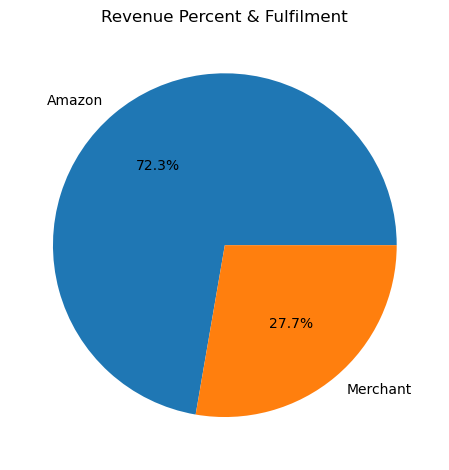

In [67]:
plt.pie(revenue_by_fulfilment['Total Revenue'],labels=revenue_by_fulfilment['Fulfilment'],autopct='%1.1f%%')
plt.title('Revenue Percent & Fulfilment')
plt.tight_layout()
plt.show()

---

### Fulfilment Analysis

**Observations:**
- Amazon fulfilment handled 72,826 orders compared with 27,516 orders through Merchant fulfilment.
- Amazon fulfilment therefore handled the majority of shipped and delivered orders.
- Amazon fulfilment generated approximately ₹5.05 Cr in revenue compared with ₹1.93 Cr from Merchant fulfilment.


---

In [68]:
# revenue according to Order Status
revenue_by_courier_status = df.groupby('Order Status Group')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_courier_status['Total Revenue'] = revenue_by_courier_status['Total Revenue'].round(2)
revenue_by_courier_status

,Order Status Group,Total Revenue
0,Shipped,51138810.6
1,Delivered,18656235.5
2,Cancelled,11840128.9
3,Returned,1386754.0
4,Pending,633800.0


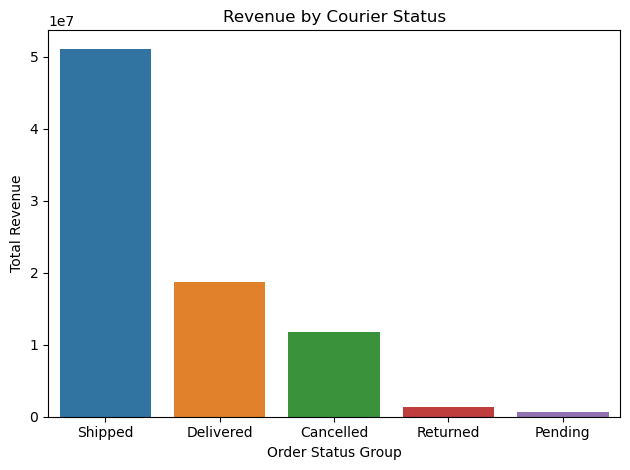

In [69]:

sns.barplot(data=revenue_by_courier_status,x='Order Status Group',y='Total Revenue')
plt.title('Revenue by Courier Status')
plt.tight_layout()
plt.show()

---

### Order Status


**Observations:**
- Shipped orders represented the largest order-status group with 78,809 orders.
- Delivered orders accounted for 28,769 orders.
- There were 18,329 cancelled, 2,109 returned and 953 pending orders.


---

In [70]:
# revenue by Service Level
total_revenue_by_service_level = revenue_df.groupby('Service Level')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
total_revenue_by_service_level['Total Revenue'] = total_revenue_by_service_level['Total Revenue'].round(2)
total_revenue_by_service_level

,Service Level,Total Revenue
0,Expedited,50342840.74
1,Standard,19452205.36


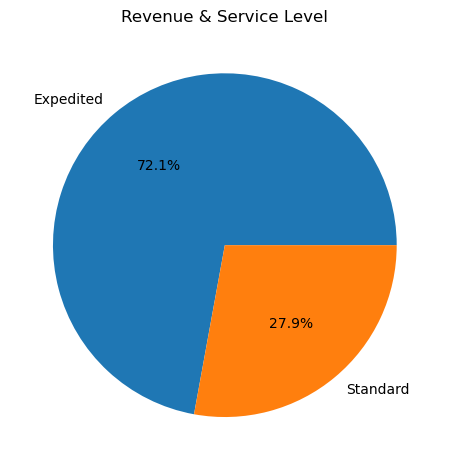

In [71]:
plt.pie(total_revenue_by_service_level['Total Revenue'],labels=total_revenue_by_service_level['Service Level'],autopct='%1.1f%%')
plt.title('Revenue & Service Level')
plt.tight_layout()
plt.show()

---


### Service Level


**Observations:**
- Expedited orders generated approximately ₹5.03 Cr in revenue.
- Standard orders generated approximately ₹1.95 Cr.
- Expedited service therefore represented the dominant service-level segment in the analysed revenue.


---

### Promotional Analysis

In [72]:
df['Promotion Applied'] = np.where(df['Promotions']!='No Promotions','Yes','No')
revenue_df = df[df['Order Status Group'].isin(['Shipped','Delivered'])]
df['Promotion Applied'].value_counts()

Promotion Applied
Yes    79819
No     49150
Name: count, dtype: int64

In [73]:
df['Promotions'].value_counts()

Promotions
No Promotions                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [74]:
# revenue by promotions
revenue_by_promotion = revenue_df.groupby('Promotion Applied')['Amount'].sum().sort_values(ascending=False).reset_index(name='Total Revenue')
revenue_by_promotion['Total Revenue'] = revenue_by_promotion['Total Revenue'].round(2)
revenue_by_promotion

,Promotion Applied,Total Revenue
0,Yes,51688164.74
1,No,18106881.36


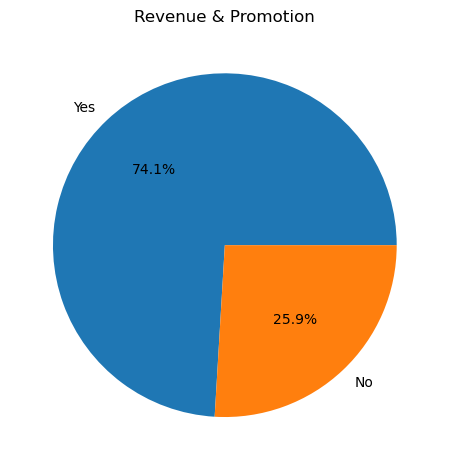

In [75]:
plt.pie(revenue_by_promotion['Total Revenue'],labels=revenue_by_promotion['Promotion Applied'],autopct='%1.1f%%')
plt.title('Revenue & Promotion')
plt.tight_layout()
plt.show()

---

### Promotional Analysis

**Observations:**
- 79,819 orders had a promotion applied, while 49,150 orders had no promotion.
- Promotion-associated orders generated approximately ₹5.17 Cr in revenue.
- Orders without promotions generated approximately ₹1.81 Cr in revenue.
- Promotional orders therefore represented a substantial share of the analysed sales mix.

----

### B2B sales analysis

In [76]:
b2b_analysis = df['B2B'].value_counts().reset_index(name='Sales Type')
b2b_analysis

,B2B,Sales Type
0,False,128098
1,True,871


**Obeservations:**
- Most of the orders are B2C which is common in E-Commerce sales

---

## Key Insights

**1. Sales declined across the available period**
- Order volume, revenue and quantity sold all declined from April to June.
- April recorded the strongest performance, while June recorded the lowest among the three months.
- This indicates a downward short-term sales pattern within the available data period.

**2. Sales are geographically concentrated**
- Maharashtra and Karnataka were the strongest states by order volume and revenue.
- Bengaluru and Hyderabad were the leading cities by both orders and revenue.
- This indicates that a relatively small number of geographic markets contribute a substantial share of sales activity.

**3. Revenue is concentrated among a few product categories**
- Set generated the highest revenue, followed by Kurta and Western Dress.
- These categories contributed substantially more revenue than the remaining categories.
- A relatively small number of product categories therefore drive a large portion of sales.

**4. Amazon fulfilment dominates the analysed orders**
- Amazon fulfilment handled substantially more shipped and delivered orders than Merchant fulfilment.
- Amazon fulfilment also generated considerably higher revenue.
- The business therefore relies heavily on Amazon's fulfilment network for order processing.

**5. Order cancellations represent a significant operational issue**
- 18,329 orders were cancelled, resulting in an overall cancellation rate of 14.28%.
- This represents a meaningful share of total orders.
- Cancellation patterns should therefore be investigated further to identify potential operational or customer-related factors.

**6. Expedited shipping represents the dominant service level**
- Expedited orders generated considerably more revenue than Standard orders.
- Expedited service also represents the majority of analysed orders.
- This suggests that expedited fulfilment is an important part of the observed sales and fulfilment mix.

**7. Promotions are associated with a substantial share of sales**
- 79,819 orders had a promotion applied, compared with 49,150 orders without a promotion.
- Promotion-associated orders generated substantially higher total revenue.
- However, this analysis shows association rather than causation, so the effectiveness of promotions would require further analysis using metrics such as average order value or revenue per order.

## Business Recommendations

**1. Monitor the short-term sales decline**
- Investigate the reasons behind the decline in orders, quantity and revenue from April to June.
- Review product demand, pricing, promotions and inventory availability to determine whether the decline is temporary or part of a broader pattern.

**2. Prioritize high-performing geographic markets**
- Maintain strong inventory availability and targeted marketing efforts in Maharashtra, Karnataka, Bengaluru and Hyderabad.
- At the same time, identify high-potential lower-performing markets for future expansion.

**3. Prioritize high-performing product categories**
- Ensure adequate inventory for major revenue-generating categories such as Set, Kurta and Western Dress.
- Review lower-performing categories to understand whether pricing, demand or product assortment needs adjustment.

**4. Investigate order cancellations**
- Analyze cancelled orders by category, fulfilment method, state, product and time period.
- Identifying the major sources of cancellations could help reduce lost sales and improve operational efficiency.

**5. Review fulfilment strategy**
- Since Amazon fulfilment handles the majority of analysed orders, monitor its performance closely.
- Compare cancellation and delivery outcomes between Amazon and Merchant fulfilment to identify opportunities for operational improvement.

**6. Evaluate the effectiveness of promotions**
- Promotions should not be evaluated only by total revenue.
- Compare promoted and non-promoted orders using metrics such as average order value, quantity per order and revenue per order to determine whether promotions are generating incremental value.

**7. Use the available data period cautiously**
- The dataset covers only a short period from March 31 to June 29, 2022.
- Future analysis using a longer time period would allow more reliable seasonal and year-over-year comparisons.